# Modelling carbonflation in the EU
This notebook models the impact of carbon price increases on inflation in different EU countries. 


## Loading Figaro IO tables
First, we have to load the Figaro database.

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import eurostat
from itertools import product
import pickle
import gzip
import logging
import warnings

# Add local directory to sys.path via relative path
local_lib_path = os.path.abspath("../python code/mrio_toolbox")
sys.path.insert(0, local_lib_path)
from mrio_toolbox import MRIO, Part, multi_scale_mapping

# Suppress warnings about duplicate dimension names specific UserWarnings from xarray.namedarray
logging.getLogger("mrio_toolbox._parts._Part").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning, module=r"xarray\.namedarray\.core")


############################
# Set script-wide parameters
############################

year = 2022  # Set the year for the analysis
version = "eu27_ch_no_without_mt_si_lv_cy" # Include switzerland and norway in the analysis, exclude Malta, Slovenia, Latvia and Cyprus
include_imports = False  # include imports of RoW in the carbon model
coverage = "ets1and2" # coverage options: "ets1", "ets1and2", "all"
start_year = 2027
end_year = 2027

In [2]:
 # Remove ROW if it exists in the list

# load figaro
figaro_file_path = os.path.abspath(f"../data/Figaro IO/formatted IO/figaro_year{year}_aggregated_{version}.nc")
figaro = MRIO(file= figaro_file_path)
countries = figaro.labels["countries"]
sectors = figaro.labels["sectors"]

# Check table balance
x_t = figaro.t.sum(axis = 0) + figaro.va.sum(axis = 0)
x_s = figaro.sup.sum(axis = 0)

np.allclose(x_t.data, x_s.data, atol = 0.2)

True

## Load emission coverage
Next, we compute emission intensities for the ETS1 and ETS2 based on the emission satellite accounts from the multi-scale-mapping algorithm. We start by collecting a list of covered emission categories.

Note: ets1 and ets2 have overlapping coverage, e.g. 1.A.1.a is contained in both. So if we want to disaggregate, then we should rather just use the effect of ets1 and the total effect and the difference is the effect of ets2. But if we compute the effect of ets1 plus that of ets2 we double count the overlapping emission categories. 

In [3]:
qt_coverage = figaro.qt.labels["Emission categories"]

ets1_coverage = pd.read_excel("../data/sectoral coverage/Emission Coverage ETS.xlsx", sheet_name="ETS1")["IPCC Source Category"].dropna().tolist()
ets1_coverage.sort()
ets1_coverage = [cat for cat in ets1_coverage if cat in qt_coverage] # remove categories that are not in qt_coverage

ets2_coverage = pd.read_excel("../data/sectoral coverage/Emission Coverage ETS.xlsx", sheet_name="ETS2")["IPCC Source Category"].dropna().tolist()
ets2_coverage.sort()
ets2_coverage = [cat for cat in ets2_coverage if cat in qt_coverage]

ets1and2_coverage = list(set(ets1_coverage).union(set(ets2_coverage)))
ets1and2_coverage.sort()

complete_coverage = []
for cat in (qt_coverage):
    if not any([cat.startswith(parent + ".") for parent in qt_coverage]):
        complete_coverage.append(cat)
complete_coverage.remove("M.0.EL") # otherwise double counting 

## Defining variables and matrices
Note: ```M["DE"]``` will not be equal to the import vector in Weber, because in our case we would only look at Germany's imports from non-EU countries and in Weber's case, we would look at all of Germany's imports. 

In [4]:
# Get matrices from figaro object
T = figaro.t # inter industry transactions
Y = figaro.y # final demand
VA = figaro.va# value added
S = figaro.sup # supply table
figaro.qt = figaro.qt * 1000 # convert from kt CO2 to t CO2
Q_ets1 = figaro.qt[["CO2", ets1_coverage], "all"].sum(on = "Emission categories") # Emissions covered from ETS1
Q_ets2 = figaro.qt[["CO2", ets2_coverage], "all"].sum(on = "Emission categories") # Emissions covered from ETS1 and ETS2
Q_ets1and2 = figaro.qt[["CO2", ets1and2_coverage], "all"].sum(on = "Emission categories") # Emissions covered from ETS1 and ETS2
Q_all = figaro.qt[["CO2", complete_coverage], "all"].sum(on = "Emission categories") # All CO2 emissions

# Transform units from million euros to euros
T = T * 1e6  # inter industry transactions in euros
Y = Y * 1e6  # final demand in euros
VA = VA * 1e6  # value added in euros
S = S * 1e6  # supply table in euros
# Q is in tons of CO2 

X_h = T.sum(axis=1) + Y.sum(axis=1) #Total output calculated in IO tables horizontally
X_v = T.sum(axis=0) + VA.sum(axis=0) #Total output calculated in IO tables vertically

if "ROW" in countries:
    countries.remove("ROW") 

# Treat imports and ROW
M = T["ROW", "all"] # imports are defined as all T matrix entries with ROW on the vertical axis
M = M["all", [countries]] # remove inter-industry ROW trade by selecting only countries other than ROW
T = T[[countries, "all"], [countries, "all"]]
S = S[[countries, "all"], [countries, "all"]] # supply table with only countries and no ROW
VA = VA["all", [countries]]
Q_ets1 = Q_ets1["all", [countries]]
Q_ets2 = Q_ets2["all", [countries]]
Q_ets1and2 = Q_ets1and2["all", [countries]]
Q_all = Q_all["all", [countries]]

# Check table balance of IO tables -> gross output should match both ways
X = T.sum(axis = 0) + M.sum(axis = 0) + VA.sum(axis = 0) # Compute gross output with imports moved from T matrix to own matrix
X_h = X_h[[countries],"all"]
X_v = X_v[[countries], "all"]
if not np.allclose(X.data, X_h.data, X_v.data, atol=0.2):
    print("Warning: Gross output arrays are not equal! The table might not be balanced.")
else:
    print("Gross output arrays are equal. The table is balanced.")

# Compute technical coefficients and shares from partitioned table without ROW
A = T / X # technical coefficients
q_ets1 = Q_ets1 / X
q_ets2 = Q_ets2 / X
q_ets1and2 = Q_ets1and2 / X
q_all = Q_all / X


# treat nans and infs
A.data = np.nan_to_num(A.data, nan=0.0)
q_ets1.data = np.nan_to_num(q_ets1.data, nan=0.0, posinf=0.0)
q_ets2.data = np.nan_to_num(q_ets2.data, nan=0.0, posinf=0.0)
q_ets1and2.data = np.nan_to_num(q_ets1and2.data, nan=0.0, posinf=0.0)
q_all.data = np.nan_to_num(q_all.data, nan=0.0, posinf=0.0)

# define q based on coverage option. Later we can extend this in order to disaggregate and use multiple q's
match coverage:
    case "ets1":
        Q = Q_ets1
        q = q_ets1
    case "ets1and2":
        Q = Q_ets1and2
        q = q_ets1and2
    case "all":
        Q = Q_all
        q = q_all
    case _:
        raise ValueError(f"Invalid coverage option: {coverage}. Choose from 'ets1', 'ets1and2', or 'all'.")

Gross output arrays are equal. The table is balanced.


/home/florian/HWR/2_Semester/Ecological_Modelling/ecological-modeling-term-paper/code and data/python code/mrio_toolbox/_parts/_Part.py:1753: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/HWR/2_Semester/Ecological_Modelling/ecological-modeling-term-paper/code and data/python code/mrio_toolbox/_parts/_Part.py:1753: RuntimeWarning: divide by zero encountered in divide
  return self.alias(data=self.data/a,


## Print emission coverage

Text(0.5, 1.0, 'Total CO2 emissions by country and coverage')

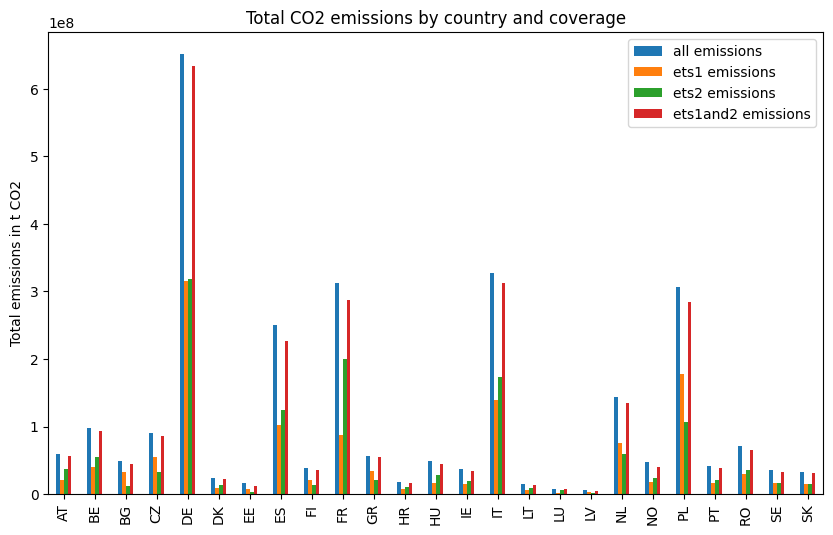

In [31]:
# Print emission coverage by country
df = pd.DataFrame(index = countries)
df["all emissions"] = Q_all.sum(on = "sectors").to_pandas()
df["ets1 emissions"] = Q_ets1.sum(on = "sectors").to_pandas()
df["ets2 emissions"] = Q_ets2.sum(on = "sectors").to_pandas()
df["ets1and2 emissions"] = Q_ets1and2.sum(on = "sectors").to_pandas()

df.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Total emissions in t CO2")
plt.title("Total CO2 emissions by country and coverage")

In [33]:
# print average emission coverage
df["share of emissions covered"] = (df["ets1and2 emissions"] / df["all emissions"])
df["share of emissions covered"].describe()

count    25.000000
mean      0.916377
std       0.057687
min       0.728640
25%       0.915278
50%       0.920474
75%       0.950924
max       0.991939
Name: share of emissions covered, dtype: float64

In [6]:
figaro.qt[["CO2", ["M.0.EL", "M.AG"]], "DE"].to_pandas()

countries                                                                               DE  \
sectors                 Crop and animal production, hunting and related service activities   
GHG Emission categories                                                                      
CO2 M.0.EL                                                    5.894480e+06                   
    M.AG                                                      6.186543e+05                   

countries                                                             \
sectors                 Forestry and logging Fishing and aquaculture   
GHG Emission categories                                                
CO2 M.0.EL                      2.559556e+06             16126.77416   
    M.AG                        0.000000e+00                 0.00000   

countries                                     \
sectors                 Mining and quarrying   
GHG Emission categories                        
CO2 M.0.EL                      2.751353e+06   
    M.AG                        0.000000e+00   

countries                                                                             \
sectors                 Manufacture of food products; beverages and tobacco products   
GHG Emission categories                                                                
CO2 M.0.EL                                                   202380.239767             
    M.AG                                                          0.000000             

countries                                                                                       \
sectors                 Manufacture of textiles, wearing apparel, leather and related products   
GHG Emission categories                                                                          
CO2 M.0.EL                                                             0.0                       
    M.AG                                                               0.0                       

countries                                                                                                                                                \
sectors                 Manufacture of wood and of products of wood and cork, except furniture; manufacture of articles of straw and plaiting materials   
GHG Emission categories                                                                                                                                   
CO2 M.0.EL                                                             0.0                                                                                
    M.AG                                                               0.0                                                                                

countries                                                        \
sectors                 Manufacture of paper and paper products   
GHG Emission categories                                           
CO2 M.0.EL                                          6508.338793   
    M.AG                                               0.000000   

countries                                                            \
sectors                 Printing and reproduction of recorded media   
GHG Emission categories                                               
CO2 M.0.EL                                              2241.530341   
    M.AG                                                   0.000000   

countries                                                                   \
sectors                 Manufacture of coke and refined petroleum products   
GHG Emission categories                                                      
CO2 M.0.EL                                                    9.693137e+07   
    M.AG                                                      0.000000e+00   

countries                ...                                        \
sectors                  ...     Education Human health activities

Interesting: With the ETS2 we cover nearly all emissions except LULUCF! 

## Carbon model

### Check unit price vector in basic model

Before setting up the carbon model, we check wether the basic price model actually produces a vector of unit prices as expected.
We can see that the Basic price model indeed produces unit prices for the unmodified v and m vectors. However, we have to sort out the zeros in the P vector. They emerge due to the fact that some sectors have zero output. Without the zeros, the price vector is within a small tolerance equal to 1. 

In [7]:
At = A.transpose()

# Define v and m vectors
v = (VA / X).transpose() 
m = (M / X).transpose()
v = v.sum(axis = 1)
m = m.sum(axis = 1)
v.data = np.nan_to_num(v.data, 0.0)
m.data = np.nan_to_num(m.data, 0.0)

# Basic Price model equation without modified v and m vector
P_unity = At.leontief_inversion().mul(v + m)

P_without_zeros = [x for x in P_unity.data if x != 0]
close = np.isclose(P_unity.data, 1.0, atol = 0.1)
diff = P_unity.data - 1.0
name = [f"{c} + {s}" for c, s in  product(P_unity.labels["countries"], P_unity.labels["sectors"])]
sum(np.isclose(P_unity.data, 1.0, atol = 0.1)) / len(P_unity.data)

balancing_df = pd.DataFrame({"name" : name, "close" : close, "diff": diff, "P_data" : P_unity.data , "X_data" : X.data})

np.allclose(P_without_zeros, 1)

/home/florian/HWR/2_Semester/Ecological_Modelling/ecological-modeling-term-paper/code and data/python code/mrio_toolbox/_parts/_Part.py:1753: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,


True

### Defining P matrix


In our actual carbon model, we will modify the v and m vectors to increase shocks to the value added section (representing increases in CO2 prices) as well as shocks to the prices of the respective import industry (non-arbitrage assumption). 

Before, we redefine the P part as an empty part object that later holds the sectoral inflation impacts of the model. 
P is a labelled square matrix. The rows show the contribution of a certain sector to the inflation of another sector. You may read this like a T matrix. Summing over the rows gives the total inflation contribution of this sector to all other sectors. Summing over the columns calculates how much each sector's prices are increased. The diagonal elements give the direct effect of a sectors carbon price increase, the off-diagonal entries are indirect effects.

In [8]:
# Variables which don't depend on country, sector or carbon price can be pre-computed for efficiency gains
all_indices = np.arange(len(figaro.labels["countries"]) * len(figaro.labels["sectors"])).tolist() #gives list of indices where each country and sector have a specific index

### Precompute Lupiv tuples
We pre-compute LU-decomposition and pivot tables and store them in a tuple. Right now the default is to only recompute countries which are not cached yet, so this function only runs one time. 
Single floating point precision is used to reduce the memory footprint, still each countrie's file is about 840 MB large, so an additional 24 GB of free disc space is required, but later we will be able to run the carbon model function much faster.

gz compression would be able to reduce the size of each country's file to about 730MB, at the expense of computational overhead for the compression both when compressing the files (nearly 50 seconds per country) as well as extracting the compressed archives (not tested). I didn't find this tradeoff between size and speed worthwile, but maybe different compression alorithms and settings are indeed more optimal than no compression. 

In [9]:
compression = False
recompute_all = False  # Set to false to just recompute for countries that don't have a cache file yet. 

# Define folder for LU cache files
lu_cache_folder = "../data/lu_cache_by_country"
os.makedirs(lu_cache_folder, exist_ok=True)  # Create folder if none exists

for country in countries:
    if recompute_all is False and os.path.exists(os.path.join(lu_cache_folder, f"lupiv_{country}_{version}_{year}.pkl")):
        print(f"LU cache for country {country} already exists. Skipping computation.")
        continue
    else:
        lu_cache_country = {}
        for sector in sectors:
            AtEE = At.remove_country_sector_combination(country, sector)
            lu, piv = AtEE.leontief_lu_factor()

            # Reduce size
            lu = lu.astype(np.float32)
            piv = piv.astype(np.int32)

            # Store factorization
            lu_cache_country[sector] = (lu, piv)

            print(f"Compute LU decomposition for  {country} - {sector}")

        if compression: 
            # Save compressed LU cache per country
            cache_path = os.path.join(lu_cache_folder, f"lupiv_{country}_{version}_{year}.pkl.gz")
            with gzip.open(cache_path, "wb") as f:
                pickle.dump(lu_cache_country, f, protocol=pickle.HIGHEST_PROTOCOL)
        else:   
            # Save as plain pickle file (no compression)
            cache_path = os.path.join(lu_cache_folder, f"lupiv_{country}_{version}_{year}.pkl")
            with open(cache_path, "wb") as f:
                pickle.dump(lu_cache_country, f, protocol=pickle.HIGHEST_PROTOCOL)

        print(f"Saved LU cache for {country} to: {cache_path}")

LU cache for country AT already exists. Skipping computation.
LU cache for country BE already exists. Skipping computation.
LU cache for country BG already exists. Skipping computation.
LU cache for country CH already exists. Skipping computation.
LU cache for country CZ already exists. Skipping computation.
LU cache for country DE already exists. Skipping computation.
LU cache for country DK already exists. Skipping computation.
LU cache for country EE already exists. Skipping computation.
LU cache for country ES already exists. Skipping computation.
LU cache for country FI already exists. Skipping computation.
LU cache for country FR already exists. Skipping computation.
LU cache for country GR already exists. Skipping computation.
LU cache for country HR already exists. Skipping computation.
LU cache for country HU already exists. Skipping computation.
LU cache for country IE already exists. Skipping computation.
LU cache for country IT already exists. Skipping computation.
LU cache

### Carbon model function

Load carbon prices

In [10]:
ets1_carbon_prices = pd.read_csv("../data/carbon prices/ets1_carbon_price_changes.csv")
ets2_carbon_prices = pd.read_csv("../data/carbon prices/ets2_carbon_price_changes.csv")
ets2_carbon_prices

,country,year,carbon_price
0,AT,2021,0.000000
1,BE,2021,0.000000
2,BG,2021,0.000000
3,HR,2021,0.000000
4,CY,2021,0.000000
...,...,...,...
295,RO,2030,16.666667
296,SK,2030,16.666667
297,ES,2030,16.666667
298,SE,2030,16.666667


In [11]:
def carbon_model(start_year, end_year, coverage, include_imports=False):  #to be done: add variable start_year=2021, end_year=2030; add variable uniform_price=False  
    """
    Calculate the carbon model for a given sector and carbon price.
    
    Parameters:
    -----------
    start_year (int): The starting year for the analysis.
    end_year (int): The ending year for the analysis.
    coverage (str): "ets1" for ETS1 coverage, "ets1and2" for ETS1 and ETS2 coverage, "all" for all emissions coverage.
    include_imports (bool): Whether to include price shocks to imports from RoW in the calculation.
    
    Returns:
    P (Part): A Part object containing the price changes for each country-sector combination.
    --------
    """
    
    # define price changes matrix for inter-industry inflation impacts
    P = T.alias(data = np.zeros(T.shape), name = "deltaP") 
    
    if coverage == "ets1":
        local_q = q_ets1
    elif coverage == "ets1and2":
        local_q = q_ets1and2
    else: 
        local_q = q_all
        
    if not include_imports:
        m = (M/X).transpose()
        m = m.sum(axis=1)
        m.data = np.nan_to_num(m.data, 0.0)

    for year_i in range(start_year, end_year+1):    
        for country in countries:
            lu_cache = pickle.load(open(os.path.join(lu_cache_folder, f"lupiv_{country}_{version}_{year}.pkl"), "rb"))
            
            #carbon_price = 0
            #if (coverage == "ets1"):
            #    carbon_price = ets1_carbon_prices.loc[ets1_carbon_prices['year'] == year_i]['carbon_price'].item()
            #elif(coverage == "ets1and2"):
            #    carbon_price = ets2_carbon_prices.loc[(ets2_carbon_prices['year'] == year_i) & (ets2_carbon_prices['country'] == country)]['carbon_price'].item()
            #elif(coverage == "all"):
            #    carbon_price = ets2_carbon_prices.loc[(ets2_carbon_prices['year'] == year_i) & (ets2_carbon_prices['country'] == country)]['carbon_price'].item()
            
            ets1_price = ets1_carbon_prices.loc[ets1_carbon_prices['year'] == year_i]['carbon_price'].item()
            ets2_price = ets2_carbon_prices.loc[(ets2_carbon_prices['year'] == year_i) & (ets2_carbon_prices['country'] == country)]['carbon_price'].item()
            
            
            print(f"calculating carbon model for country: {country}")
            for sector in sectors:
                if (coverage == "ets1"):
                    tau = ets1_price * q_ets1["CO2"]
                elif(coverage == "ets1and2"):
                    tau = ets1_price * q_ets1["CO2"] + ets2_price * q_ets2["CO2"]
                elif(coverage == "all"):
                    raise NotImplementedError("Coverage 'all' is not yet implemented for carbon pricing.")
                
                
                # Price shock vector: apply carbon price to unit emissions (note: q is already emissions per unit of output in euros)
                pX = tau["CO2", [country, sector]].data.item() # get scalar of price change from tau        
                pX = 1 + pX 
                if include_imports:
                    # Import price shock to imports from non-EU countries
                    M_shocked = M.copy()
                    M_shocked[["ROW", sector],"all"] *= pX # apply price shock to the respective sector in the imports Matrix
                    m = (M_shocked / X).transpose() 
                    m = m.sum(axis = 1)
                    m.data = np.nan_to_num(m.data, 0.0)
                
                # Setting up partitioned tables
                # AtEE in our case is pre-computed in the LU cache
                AtXE = At[["all"],[country, sector]].remove_country_sector_combination(country, sector, axis = 0) # This gives endogenous sectors on axis 0 and the endogenous combination on axis 1
                mE = m.remove_country_sector_combination(country, sector) # endogenous part of imports
                vE = v.remove_country_sector_combination(country, sector) # endogenous part of value added
                
                # equation: P = (I - AtEE)^-1 * AtXE * pX + (I - AtEE)^-1 * (vE + mE)
                lupiv = lu_cache[sector]  # Load LU factorization from cache
                Pe = Part.lu_solver(lupiv, AtXE) * pX + Part.lu_solver(lupiv, (vE + mE))  # solve the linear system using LU factorization
                
                # use setter function with indices to store results in P Part
                index = P.axes[0].get(args =[country, sector])[0] # Get the index for the country and sector combination
                indices_ex = [i for i in all_indices if i != index]  # Get all indices except the one for the country and sector combination
                P[index, index] = pX
                P[index, indices_ex] = Pe.data
        return P 

In [12]:
# Profile performance of the carbon_model function

# %load_ext line_profiler # load profiler extension. You may want to install it with pip install line_profiler
# %lprun -f carbon_model carbon_model(100) # run function with profiler
# We see that the highest time consumption is in the loading of the LU cache (ca. 50 percent) and then in the LU solver function (ca 20 percent).

In [13]:
imp = "_with_imports" if include_imports else "" 
year_range = f"{start_year}-{end_year-1}"

inflation_matrix_path = "../data/computed inflation matrices"
figure_path = f"../figures/{coverage}"
# if the figure path does not exist, create it
os.makedirs(figure_path, exist_ok=True)

file_path = os.path.join(inflation_matrix_path, f"deltaP_{year_range}{imp}{coverage}_{version}_{year}.nc")


# load the deltaP part from disk or compute a version with a new carbon price
if os.path.isfile(file_path):
    deltaP = figaro.load_part(file = file_path, standalone = True)
else:
    P = carbon_model(start_year = start_year, 
                     end_year = end_year, 
                     include_imports = include_imports,
                     coverage = coverage)
    P.data[P.data == 0] = 1.0  # Set all zero entries which result from zero output in that sector to 1.0 (no price change)
    deltaP = (P - 1) * 100 # convert to percentage change
    deltaP.save(file_path)  

# After running the carbon model, we remove Switzerland from the analysis, as it has no CPA -> COICOP mappints. 
countries = [c for c in countries if c not in ["CH"]]
deltaP = deltaP[[countries], [countries]]   
S = S[[countries], [countries]]
X = X[[countries], "all"]
q_ets1 = q_ets1["all", [countries, "all"]]
q_ets1and2 = q_ets1and2["all", [countries, "all"]]
q_all = q_all["all", [countries, "all"]]

/home/florian/HWR/2_Semester/Ecological_Modelling/ecological-modeling-term-paper/code and data/python code/mrio_toolbox/_parts/_Part.py:1753: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,


calculating carbon model for country: AT
calculating carbon model for country: BE
calculating carbon model for country: BG
calculating carbon model for country: CH
calculating carbon model for country: CZ
calculating carbon model for country: DE
calculating carbon model for country: DK
calculating carbon model for country: EE
calculating carbon model for country: ES
calculating carbon model for country: FI
calculating carbon model for country: FR
calculating carbon model for country: GR
calculating carbon model for country: HR
calculating carbon model for country: HU
calculating carbon model for country: IE
calculating carbon model for country: IT
calculating carbon model for country: LT
calculating carbon model for country: LU
calculating carbon model for country: LV
calculating carbon model for country: NL
calculating carbon model for country: NO
calculating carbon model for country: PL
calculating carbon model for country: PT
calculating carbon model for country: RO
calculating carb

Attribute groupings is a dict. It will not be saved.
Attribute metadata is a dict. It will not be saved.


## Transform industry inflation impact to hicp impact
### From NACE2 to CPA to COICOP to HICP
To get from the sectoral inflation to the CPI impact, we go throught he following steps: 
1. We now transform sectoral inflation impacts on the industry level to the product level using our market share matrix. 
2. Then, we transform this to the COICOP level using [this bridging matrix](https://www.sciencedirect.com/science/article/pii/S2352340920302894#ecom0002). We will assume that intertemporal stability of the briding coefficients for the year 2015 holds, following [Kronenberg 2011](https://io4.shaio.es/paper/pap15.pdf). 
3. Then, we will compute inflation impact using the hicp inflation weights from eurostat. 

Before we actually compute the transformations, we have to run some sanity checks and harmonization on our transformation matrices. 

### Prepare supply tables: Check for balance and compute market share matrix
Take a look at our supply table: We see that we have products as rows and industries as columns

In [14]:
S.to_pandas().head(5)

countries                                                                                                                    AT  \
sectors                                                      Crop and animal production, hunting and related service activities   
countries cpa_labs                                                                                                                
AT        Products of agriculture, hunting and related se...                                       9.164979e+09                   
          Products of forestry, logging and related services                                       0.000000e+00                   
          Fish and other fishing products; aquaculture pr...                                       0.000000e+00                   
          Mining and quarrying                                                                     3.730000e+06                   
          Food, beverages and tobacco products                                                     9.874560e+08                   

countries                                                                          \
sectors                                                      Forestry and logging   
countries cpa_labs                                                                  
AT        Products of agriculture, hunting and related se...         0.000000e+00   
          Products of forestry, logging and related services         3.210496e+09   
          Fish and other fishing products; aquaculture pr...         0.000000e+00   
          Mining and quarrying                                       0.000000e+00   
          Food, beverages and tobacco products                       0.000000e+00   

countries                                                                             \
sectors                                                      Fishing and aquaculture   
countries cpa_labs                                                                     
AT        Products of agriculture, hunting and related se...                     0.0   
          Products of forestry, logging and related services                     0.0   
          Fish and other fishing products; aquaculture pr...             108076000.0   
          Mining and quarrying                                                   0.0   
          Food, beverages and tobacco products                                   0.0   

countries                                                                          \
sectors                                                      Mining and quarrying   
countries cpa_labs                                                                  
AT        Products of agriculture, hunting and related se...         0.000000e+00   
          Products of forestry, logging and related services         0.000000e+00   
          Fish and other fishing products; aquaculture pr...         0.000000e+00   
          Mining and quarrying                                       2.003368e+09   
          Food, beverages and tobacco products                       3.967100e+07   

countries                                                                                                                  \
sectors                                                      Manufacture of food products; beverages and tobacco products   
countries cpa_labs                                                                                                          
AT        Products of agriculture, hunting and related se...                                       0.000000e+00             
          Products of forestry, logging and related services                                       0.000000e+00             
          Fish and other fishing products; aquaculture pr...                                       0.000000e+00             
          Mining and quarrying                                                                     0.000000e+00             
         

When summing over all rows of the supply matrix, we should get the gross nominal value of products produced by each industry. This corresponds to gross output. First we take a look at the raw tables before we removed RoW: 

In [15]:
X_s_original = figaro.sup.sum(axis = 0)
X_original = figaro.t.sum(axis = 0) + figaro.va.sum(axis = 0)
X_original2 = figaro.t.sum(axis = 1) + figaro.y.sum(axis = 1)

np.allclose(X_s_original.data, X_original.data, X_original2.data, atol = 0.2)

True

We see that the totals are all close within an absolute tolarance of 0.2 million euros. However, once we have moved the RoW to the import section, calculating the row sums without RoW results in some inaccuracies as can be seen below. The highest relative difference between the gross output from the T, value added and supply tables is 23 percent! 

Right now I can only explain this phenomenon by inconsistencies in national supply and IO tables which got provided to eurostat. It is easy to balance the aggregates of IO and supply tables with an RAS algorithm and we can see that eurostat did this. But somehow Malta reported 23 percent more output of its coke and petroleum industry for domestic and intra-European trade in its supply table than in its IO table (hint: you can see this by clicking sort: descending on the dataframe view).  It is only when we take into account trade with the rest of the world that the gross output is equal again between the supply and IO tables. 

Still, the average relative difference between supply and IO tables is very small, so there is no big problem. For calculating the market share table (supply table / gross output) we can refer to the gross output calculated via the supply table to address Malta's special situation. 

In [16]:
X_s = S.sum(axis = 0)

names = [f"{c} + {s}" for c, s in  product(X_s.labels["countries"], X_s.labels["sectors"])]
diff = X_s.data - X.data
relative_diff = diff / X.data * 100  # Calculate relative difference in percent
balancing_df = pd.DataFrame({"names": names, "diff": diff, "relative diff": relative_diff, "x_t": X.data, "x_s": X_s.data})
average_relative_diff = balancing_df["relative diff"].mean()
print(f"The average relative difference between the supply and IO table gross output is {average_relative_diff:.4f} percent")
print(f"The median relative difference between the supply and IO table gross output is {balancing_df['relative diff'].median():.4f} percent")
print(f"The maximum relative difference between the supply and IO table gross output is {balancing_df['relative diff'].max():.4f} percent")

balancing_df

The average relative difference between the supply and IO table gross output is 0.0107 percent
The median relative difference between the supply and IO table gross output is 0.0009 percent
The maximum relative difference between the supply and IO table gross output is 1.8009 percent


/tmp/ipykernel_18959/3756425596.py:5: RuntimeWarning: invalid value encountered in divide
  relative_diff = diff / X.data * 100  # Calculate relative difference in percent


,names,diff,relative diff,x_t,x_s
0,"AT + Crop and animal production, hunting and r...",81000.0,0.000767,1.055485e+10,1.055493e+10
1,AT + Forestry and logging,87000.0,0.002649,3.284321e+09,3.284408e+09
2,AT + Fishing and aquaculture,66000.0,0.060002,1.099970e+08,1.100630e+08
3,AT + Mining and quarrying,79000.0,0.003065,2.577357e+09,2.577436e+09
4,AT + Manufacture of food products; beverages a...,27000.0,0.000083,3.253008e+10,3.253011e+10
...,...,...,...,...,...
1595,SK + Activities of membership organisations,116000.0,0.018655,6.218150e+08,6.219310e+08
1596,SK + Repair of computers and personal and hous...,107000.0,0.051848,2.063710e+08,2.064780e+08
1597,SK + Other personal service activities,82000.0,0.010270,7.984750e+08,7.985570e+08
1598,SK + Activities of households as employers; un...,0.0,0.000000,5.123100e+07,5.123100e+07


Now that we have checked the balance of our supply matrix, we can normalize it and compute the market share matrix by dividing each column of S by the respective column sum.

In [17]:
C = S / X_s
C.data = np.nan_to_num(C.data, nan=0.0) 

/home/florian/HWR/2_Semester/Ecological_Modelling/ecological-modeling-term-paper/code and data/python code/mrio_toolbox/_parts/_Part.py:1753: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,


###  Harmonize hicp data
Aggregate residual categories CP122 to CP127 to harmonize Coicop labels between the datasets for hicp weights and the bridge matrix

In [18]:
# prepare hicp data
hicp = pd.read_csv("../data/HICP weights/estat_prc_hicp_inw_filtered_en.csv")
hicp = hicp[hicp["TIME_PERIOD"] == year]

# replace "EL" with "GR" for Greece
hicp["geo"] = hicp["geo"].replace({"EL": "GR"})

hicp["coicop"] = hicp["coicop"].replace({
    "CP122": "CP122_127",
    "CP123": "CP122_127",
    "CP124": "CP122_127",
    "CP125": "CP122_127",
    "CP126": "CP122_127",
    "CP127": "CP122_127"
})
hicp = hicp[hicp["geo"].isin(countries)]  # Filter for countries in the MRIO model
#hicp = hicp.groupby(["coicop", "geo", "TIME_PERIOD"], as_index=False)["OBS_VALUE"].sum()
hicp = hicp.groupby(["geo", "coicop", "TIME_PERIOD"], as_index=False)["OBS_VALUE"].sum()
coicop_labs = hicp["coicop"].drop_duplicates().to_list()

### Compute inflation impact

A note on the following matrixes: 
- dP_csd is the total euro-wide inflation caused by a specific sector in a specific country
  - dP_csd_d is its direct component (the inflation the sector caused on itself)
  - dP_csd_i is its indirect component
- dp_rec is the total euro-wide inflation that a specific sector in a specific country received from all other european sectors (and potentially imports from RoW)
  - dp_rec_d is its direct component and is equivalent to dP_csd_d
  - dp_rec_i is its indirect component

Later when cycling through the countries, we will also compute caused and received inflation only for national industries without cross-border inflation propagation to facilitate comparability with Weber et al.

In [19]:
# direct and indirect received and caused inflation in NACE classification
dP_csd = deltaP.sum(axis=1).alias(data = deltaP.sum(axis = 1))
dP_csd_d = dP_csd.alias(data = deltaP.data.diagonal()) 
dP_csd_i = dP_csd.alias(data = dP_csd.data - dP_csd_d.data) 
dP_rec = deltaP.sum(axis=0).alias(data = deltaP.sum(axis = 0))
dP_rec_d = dP_csd_d
dP_rec_i = dP_csd.alias(data = dP_rec.data - dP_rec_d.data)

# convert to cpa classification
dP_rec_cpa = C.mul(dP_rec)
dP_rec_d_cpa = C.mul(dP_rec_d)
dP_rec_i_cpa = C.mul(dP_rec_i)

# Create empty part objects to store results in CCP and weighted CCP
coicop_labs = hicp["coicop"].drop_duplicates().to_list()

dP_rec_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])
dP_rec_d_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])
dP_rec_i_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])

sectoral_rec = Part(labels = [[{"countries":countries}],[{"sectors":sectors}]])
sectoral_rec_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])

# create new dataframe to store computed hicp inflation impacts 
df = pd.DataFrame(index = countries)
df["rec"] = dP_rec.sum(on="sectors").data
df["rec_d"] = dP_rec_d.sum(on="sectors").data
df["rec_i"] = dP_rec_i.sum(on="sectors").data

In [20]:
for country in countries:

    # prepare bridging matrix
    bridging_matrix_df = pd.read_excel("../data/CPA to COICOP mapping/bridging_matrix_2016.xlsx", sheet_name=country, header=0, index_col=0)
    bridging_matrix_df = bridging_matrix_df.drop('CP042',axis=1) # imputed rents are not in hicp data
    
    # append row for CPA_U so matrix multiplication works (CPA_U is always 0)
    series = np.zeros(len(bridging_matrix_df.columns), dtype=float)
    bridging_matrix_df.loc["CPA_U"] = series 
    
    # make new part object for the bridging matrix of each country
    data = bridging_matrix_df.to_numpy(dtype=float)
    cpa_labs = bridging_matrix_df.index.tolist()
    coicop_labs = bridging_matrix_df.columns.tolist()
    bridging_matrix = Part(data = data, name = "bridging_matrix", labels = [cpa_labs, coicop_labs])
    bridging_matrix = bridging_matrix.transpose()  # coicop labels on vertical axis
    bridging_matrix /= bridging_matrix.sum(axis=0)  # normalize
    bridging_matrix.data = np.nan_to_num(bridging_matrix.data, nan=0.0)
    
    # load hicp weights for the country
    hicp_weights = hicp[hicp["geo"] == country]["OBS_VALUE"].to_numpy()
    hicp_weights = hicp_weights / 1000 # normalize hicp weights to sum to 1
    
    # national-only received inflation in cpa
    dP_rec_nat = deltaP[country, country].sum(axis=0).alias(data = deltaP[country, country].sum(axis = 0))
    dP_rec_nat_cpa = C[country, country].mul(dP_rec_nat) 
    
    # cpa -> coicop classifcation
    dP_rec_ccp[country, "all"] = bridging_matrix.mul(dP_rec_cpa[country, "all"])
    dP_rec_d_ccp[country, "all"] = bridging_matrix.mul(dP_rec_d_cpa[country, "all"])
    dP_rec_i_ccp[country, "all"] = bridging_matrix.mul(dP_rec_i_cpa[country, "all"])
    dP_rec_nat_ccp = bridging_matrix.mul(dP_rec_nat_cpa[country, "all"])
    
    # coicop -> hicp 
    df.loc[country, "rec_hicp"] = hicp_weights @ dP_rec_ccp[country, "all"].data
    df.loc[country, "rec_d_hicp"] = hicp_weights @ dP_rec_d_ccp[country, "all"].data
    df.loc[country, "rec_i_hicp"] = hicp_weights @ dP_rec_i_ccp[country, "all"].data
    df.loc[country, "rec_nat_hicp"] = hicp_weights @ dP_rec_nat_ccp.data
 
    # average relative and absolute emission intensity of the country in tCO2 per million € output
    df.loc[country, "avg_q"] = q["CO2", country].sum(axis=1).data * 1e6
    df.loc[country, "avg_Q"] = Q["CO2", country].sum(axis=1).data * 1e6
    
    # sector-specific contribution to hicp exposure
    for sector in sectors:
        # shock each sector individually to see its exposure to HICP inflation from all other sectors
        rec_NACE = dP_rec.alias(data = np.zeros(dP_rec.shape))
        rec_NACE[country,sector] = dP_rec[country, sector]
        
        # nace -> cpa
        sectoral_rec_cpa = C.mul(rec_NACE)
        # cpa -> coicop
        sectoral_rec_ccp[country, "all"] = bridging_matrix.mul(sectoral_rec_cpa[country, "all"]) 
        # coicop -> hicp
        sectoral_rec[country, sector] = hicp_weights @ sectoral_rec_ccp[country, "all"].data
    
# imported inflation from other european countries    
df["rec_from_foreign"] = df["rec_hicp"] - df["rec_nat_hicp"]

/home/florian/HWR/2_Semester/Ecological_Modelling/ecological-modeling-term-paper/code and data/python code/mrio_toolbox/_parts/_Part.py:1753: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/HWR/2_Semester/Ecological_Modelling/ecological-modeling-term-paper/code and data/python code/mrio_toolbox/_parts/_Part.py:1753: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/HWR/2_Semester/Ecological_Modelling/ecological-modeling-term-paper/code and data/python code/mrio_toolbox/_parts/_Part.py:1753: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/HWR/2_Semester/Ecological_Modelling/ecological-modeling-term-paper/code and data/python code/mrio_toolbox/_parts/_Part.py:1753: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/HWR/2_Semester/Ecological_Modelling/ecological-modeling-te

### Adding GDP and population variables to main dataframe

In [21]:
if not os.path.exists("../data/sociodemographic_data/gdp_data.csv") or not os.path.exists("../data/sociodemographic_data/population_data.csv"):
    print("Sociodemographic data files not found. Downloading from Eurostat...")
    gdp_df = eurostat.get_data_df("nama_10_gdp") 
    pop_df = eurostat.get_data_df("demo_pjangroup")
    # save sociodemographic data to csv file
    path = "../data/sociodemographic_data"
    os.makedirs(path, exist_ok=True)  # Create directory if it doesn't exist
    gdp_df.to_csv(os.path.join(path, "gdp_data.csv"), index=False)
    pop_df.to_csv(os.path.join(path, "population_data.csv"), index=False)
else:
    # load sociodemographic data from csv files
    gdp_df = pd.read_csv("../data/sociodemographic_data/gdp_data.csv")
    pop_df = pd.read_csv("../data/sociodemographic_data/population_data.csv")

In [22]:
# rename EL to GR in both dataframes
gdp_df["geo\\TIME_PERIOD"] = gdp_df["geo\\TIME_PERIOD"].replace({"EL": "GR"})
pop_df["geo\\TIME_PERIOD"] = pop_df["geo\\TIME_PERIOD"].replace({"EL": "GR"})

gdp_df = gdp_df[
    (gdp_df["geo\\TIME_PERIOD"].isin(countries)) & # filter for the year 2022
    (gdp_df["na_item"] == "B1GQ") & # GDP (gross domestic product at market prices)
    (gdp_df["unit"] == "CP_MEUR") # current prices, million euro
    ][["geo\\TIME_PERIOD", "2022"]]

pop_df = pop_df[
    (pop_df["geo\\TIME_PERIOD"].isin(countries)) &
    (pop_df["age"] == "TOTAL") &
    (pop_df["sex"] == "T")
][["geo\\TIME_PERIOD", "2022"]].reset_index(drop=True)

df["GDP"] = gdp_df.set_index("geo\\TIME_PERIOD")["2022"].astype(float) 
df["POP"] = pop_df.set_index("geo\\TIME_PERIOD")["2022"].astype(float)
df["GDP_per_capita"] = df["GDP"] / df["POP"]

# Data analysis
Now we are ready to analyze our data. First we look not at the HICP itself but take a step back to our deltaP matrix in order to identify which sectors are most relevant for upstream inflation generation (horizontal sum of columns) or downstream inflation exposure (vertical sum of rows). 

## Inflation impact and exposure by sector


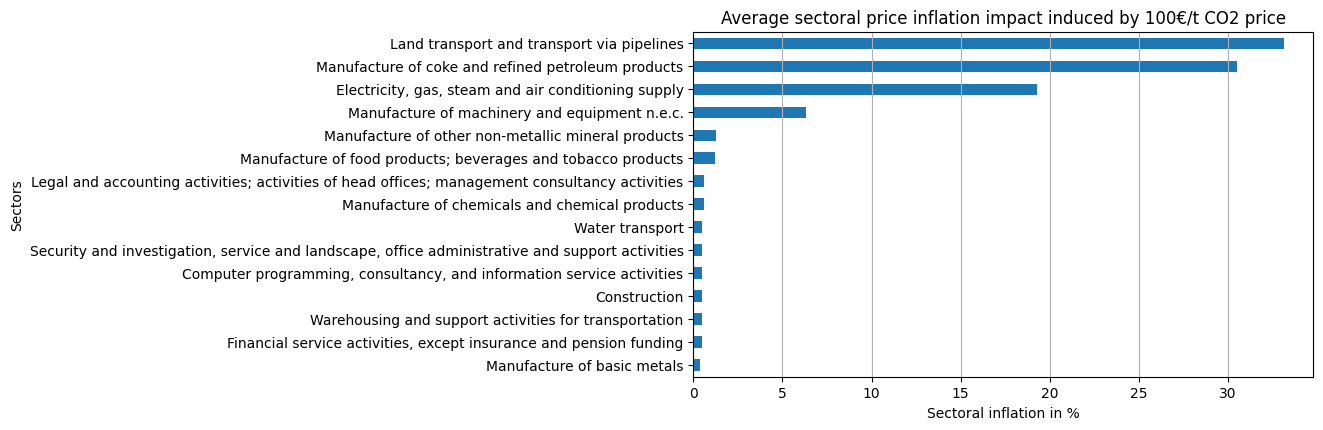

In [23]:
series = pd.Series(dP_csd.sum(on="countries").data, index = sectors).sort_values()/len(countries)
series = series.tail(15)

plt.figure(figsize=(8, len(sectors) * 0.07))
series.plot(kind="barh")
plt.xlabel("Sectoral inflation in %")
plt.ylabel("Sectors")
plt.title("Average sectoral price inflation impact induced by 100€/t CO2 price")
plt.grid(axis='x')
plt.savefig(os.path.join(figure_path, "hbar_sectoral_impact.png"), bbox_inches='tight', dpi=300)
plt.show()

<Figure size 800x320 with 0 Axes>

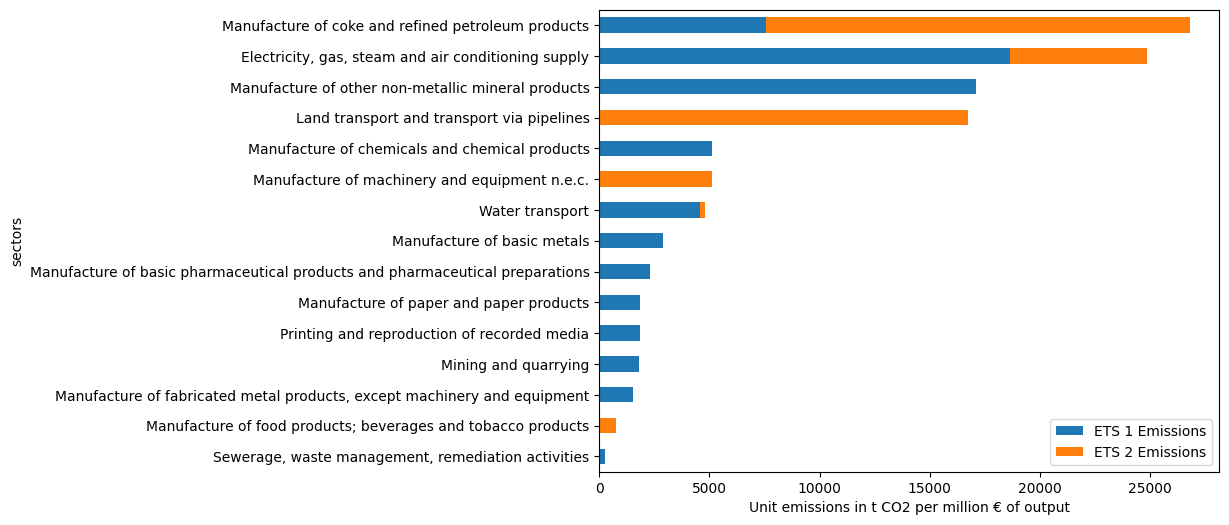

In [24]:
q_df = pd.DataFrame()
q_df["ETS 1 Emissions"] = q_ets1["CO2", "all"].sum(on="countries").to_pandas() * 1e6 # convert to tons of CO2 / million euros
q_df["ETS 1 and 2 Emissions"] = q_ets1and2["CO2", "all"].sum(on="countries").to_pandas() * 1e6  # convert to tons of CO2 / million euros
q_df["All Emissions"] = q_all["CO2", "all"].sum(on="countries").to_pandas() * 1e6  # convert to tons of CO2 / million euros
q_df["ETS 2 Emissions"] = q_df["ETS 1 and 2 Emissions"] - q_df["ETS 1 Emissions"]

plt.figure(figsize=(8, len(sectors) * 0.05))
ax = q_df.sort_values(by = ["ETS 1 and 2 Emissions"])[["ETS 1 Emissions", "ETS 2 Emissions"]].tail(15).plot(kind="barh", figsize=(8, 6), stacked=True)
plt.xlabel("Unit emissions in t CO2 per million € of output")
plt.savefig(os.path.join(figure_path, "hbar_unit_emissions.png"), bbox_inches='tight', dpi=300)
plt.show()

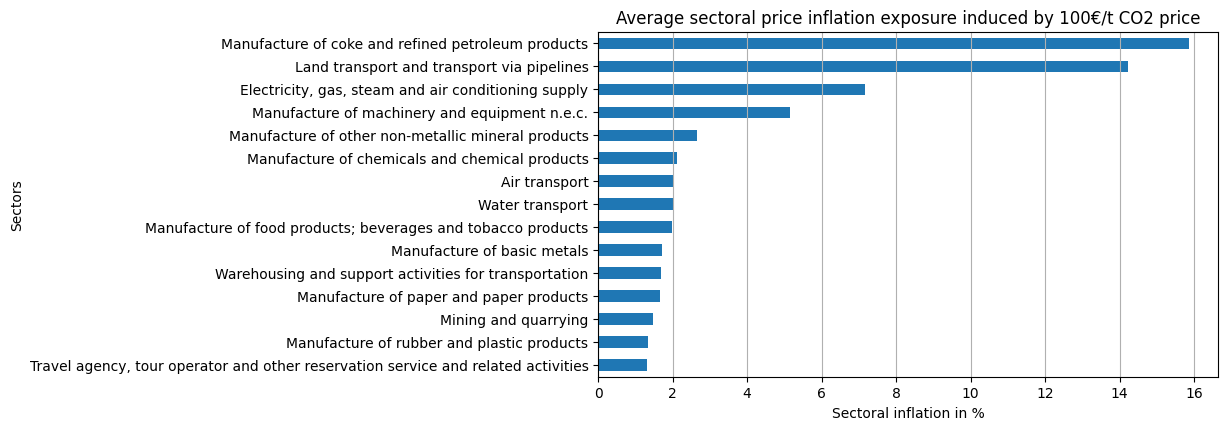

In [25]:
series = pd.Series(dP_rec.sum(on="countries").data, index = sectors).sort_values()/len(countries)
series = series.tail(15)

plt.figure(figsize=(8, len(sectors) * 0.07))
series.plot(kind="barh")
plt.xlabel("Sectoral inflation in %")
plt.ylabel("Sectors")
plt.title("Average sectoral price inflation exposure induced by 100€/t CO2 price")
plt.grid(axis='x')
plt.savefig(os.path.join(figure_path, "hbar_sectoral_exposure.png"), bbox_inches='tight', dpi=300)
plt.show()

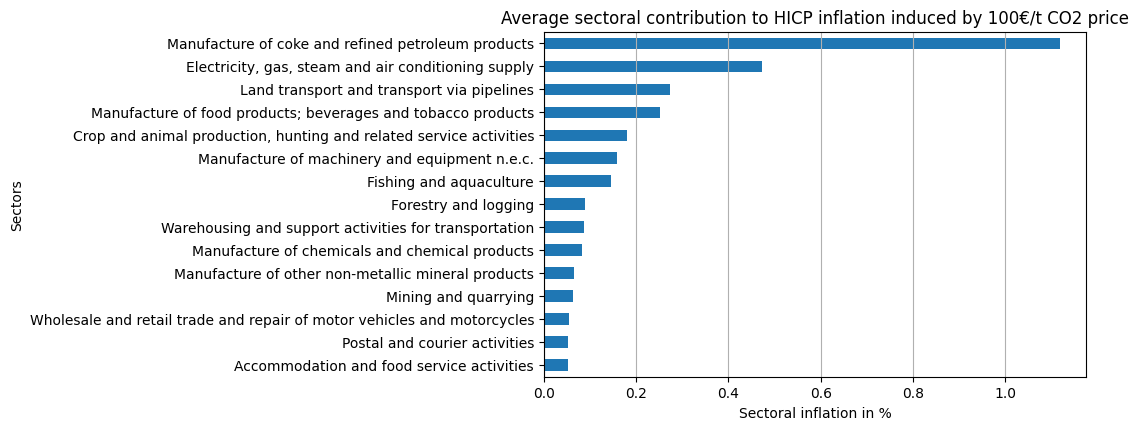

In [26]:
series = pd.Series(sectoral_rec.sum(axis=0).data, index = sectors).sort_values()/len(countries)
series = series.tail(15)

plt.figure(figsize=(7, len(sectors) * 0.07))
series.plot(kind="barh")
plt.xlabel("Sectoral inflation in %")
plt.ylabel("Sectors")
plt.title("Average sectoral contribution to HICP inflation induced by 100€/t CO2 price")
plt.grid(axis='x')
plt.savefig(os.path.join(figure_path, "hbar_sectoral_contribution_to_hicp.png"), bbox_inches='tight', dpi=300)
plt.show()

### Inflationary exposure per country by sector

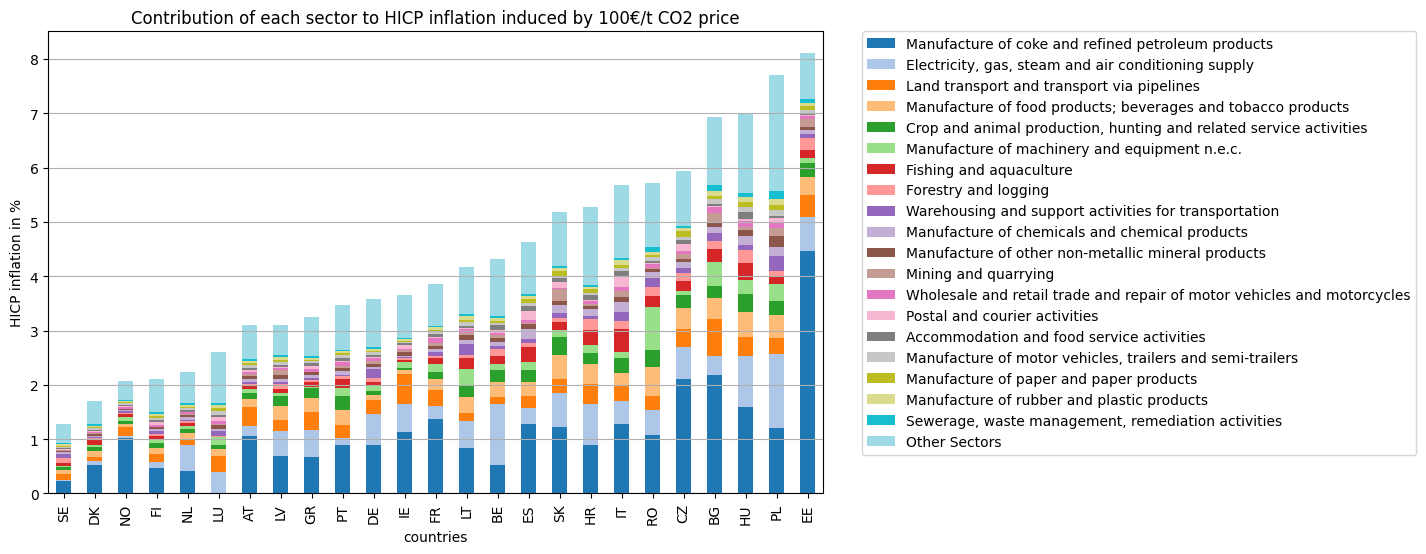

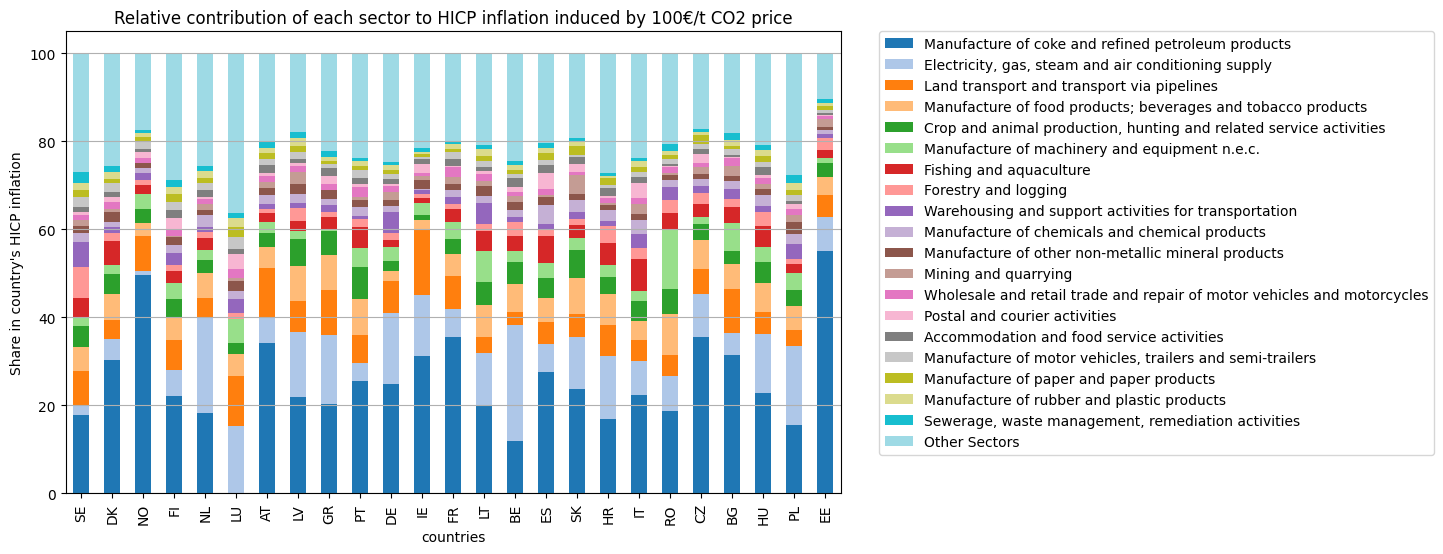

In [27]:
exposure_df = sectoral_rec.to_pandas()
exposure_df = exposure_df.transpose()
exposure_df["aggr_sectoral_exposure"] = exposure_df.sum(axis=1)
exposure_df = exposure_df.sort_values(by="aggr_sectoral_exposure", ascending=False)
top9 = exposure_df.head(19)
other = pd.DataFrame(exposure_df.iloc[19:].sum(axis=0)).transpose()
other.index = ["Other Sectors"]
exposure_df = pd.concat([top9, other])
exposure_df = exposure_df.drop(columns=["aggr_sectoral_exposure"])
exposure_df = exposure_df.transpose()
exposure_df["aggr_sectoral_exposure"] = exposure_df.sum(axis=1)
exposure_df = exposure_df.sort_values(by="aggr_sectoral_exposure", ascending=True)
normalized_exposure = exposure_df.div(exposure_df["aggr_sectoral_exposure"], axis=0) * 100  # Normalize to percentage
exposure_df = exposure_df.drop(columns=["aggr_sectoral_exposure"])


cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(exposure_df.shape[1])]

ax = exposure_df.plot(kind = "bar", stacked=True, figsize=(10, 6), color = colors)
ax.grid(axis='y')
plt.title("Contribution of each sector to HICP inflation induced by 100€/t CO2 price")
plt.ylabel("HICP inflation in %")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.savefig(os.path.join(figure_path, "bar_hicp_by_country_sector.png"), bbox_inches='tight', dpi=300)
plt.show()

normalized_exposure = normalized_exposure.drop(columns=["aggr_sectoral_exposure"])
ax = normalized_exposure.plot(kind = "bar", stacked=True, figsize=(10, 6), color = colors)
ax.grid(axis='y')
plt.title("Relative contribution of each sector to HICP inflation induced by 100€/t CO2 price")
plt.ylabel("Share in country's HICP inflation")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.savefig(os.path.join(figure_path, "bar_hicp_by_country_sector_normalized.png"), bbox_inches='tight', dpi=300)
plt.show()

### Inflation exposure by sector
Those are the downstream sectors most exposed to inflationary pressure from carbon taxes. EU-average with cross-country price propagation

### EU-wide inflation impact and exposure of each country

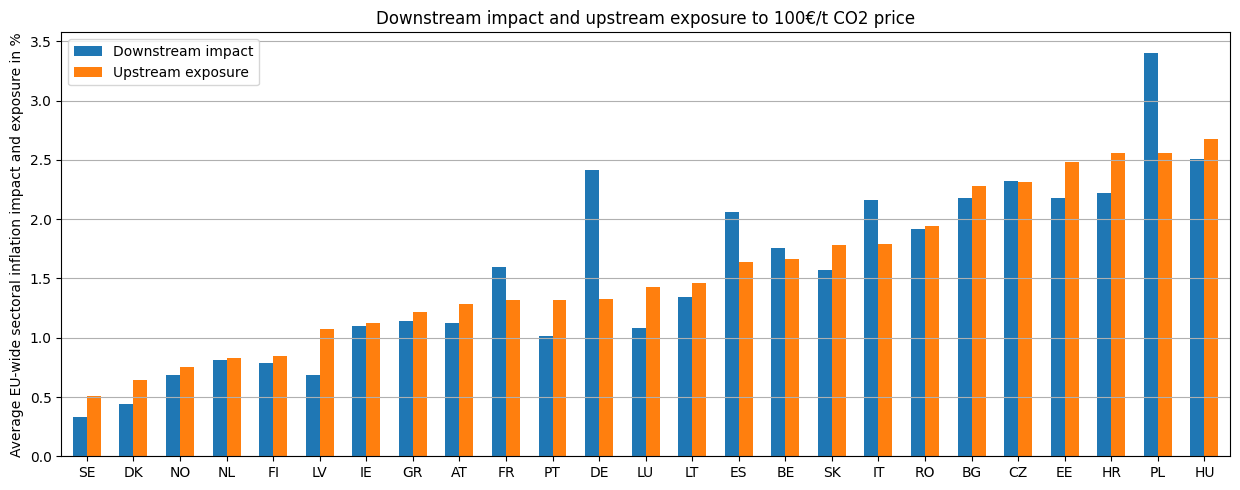

In [28]:

df["csd_aggr"] = dP_csd.sum(on="sectors").data /len(sectors)
df["rec_aggr"] = dP_rec.sum(on="sectors").data /len(sectors)

df_sorted = df.sort_values(by="rec_aggr")

ax = df_sorted[["csd_aggr", "rec_aggr"]].plot.bar(
    figsize=(0.5 * len(countries), 5),
    rot=0,
    width=0.6, 
    title="Downstream impact and upstream exposure to 100€/t CO2 price",
)
ax.grid(axis="y") 
ax.set_ylabel("Average EU-wide sectoral inflation impact and exposure in %")
ax.legend(["Downstream impact", "Upstream exposure"])#

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "bar_average_regional_impact_exposure.png"), bbox_inches='tight', dpi=300)
plt.show()

## Heatmaps

### Absolute deltaP by sector

In [29]:
values = deltaP["DE", "DE"].sum(on="countries").data
n_rows, n_cols = values.shape

plt.figure(figsize=(12, 10))
plt.imshow(values, cmap='viridis', aspect='auto')

plt.xticks(ticks=np.arange(n_cols), rotation=90)
plt.yticks(ticks=np.arange(n_rows))

plt.colorbar(label='ΔP (aggregated)')
plt.title("Inflation Impact and Exposure by Sector")
plt.xlabel("To sector")
plt.ylabel("From sector")
plt.tight_layout()
plt.show()
plt.show()

KeyboardInterrupt: 

### Normalized deltaP by sector

In [ ]:
values = abs(deltaP.sum(on = "countries").data)/len(countries)
values[values == 0] = 1e-6  # Avoid log(0) by replacing zeros with a small value

n_rows, n_cols = values.shape

plt.figure(figsize=(12, 10))
plt.imshow(values, cmap='viridis', aspect='auto', norm=LogNorm())

# Set all ticks and labels
plt.xticks(ticks=np.arange(n_cols), rotation=90)
plt.yticks(ticks=np.arange(n_rows))


plt.colorbar(label='ΔP')
plt.title("Average sectoral inflation impact and exposure (log scale)")
plt.xlabel("To sector")
plt.ylabel("From sector")
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "heatmap_sectors_normalized.png"), bbox_inches='tight', dpi=300)
plt.show()


### Normalized deltaP by country and sector

In [ ]:
values = abs(deltaP.data)
values[values == 0] = 1e-6  # Avoid log(0)
values[values < 1e-6] = 1e-6
values[values > 0.01] = 0.01 

n_rows, n_cols = values.shape

# Assuming 64 sectors per country
sectors_per_country = 64
num_countries_x = n_cols // sectors_per_country
num_countries_y = n_rows // sectors_per_country

# Centered tick positions
x_ticks = np.arange(sectors_per_country // 2, n_cols, sectors_per_country)
y_ticks = np.arange(sectors_per_country // 2, n_rows, sectors_per_country)

# Labels (truncate if necessary)
x_labels = countries[:len(x_ticks)]
y_labels = countries[:len(y_ticks)]

plt.figure(figsize=(12, 10))
plt.imshow(values, cmap='viridis', aspect='auto', norm=LogNorm())

plt.colorbar(label='ΔP')
plt.title("Inflation Impact and Exposure (countries x sectors, log scale)")
plt.xlabel("To country/sector")
plt.ylabel("From country/sector")

# Centered country labels
plt.xticks(ticks=x_ticks, labels=x_labels)
plt.yticks(ticks=y_ticks, labels=y_labels)

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "heatmap_countries_sectors.png"), bbox_inches='tight', dpi=300)
plt.show()


#### Index mapping

In [ ]:
n = len(countries)
n_cols = 2
n_rows = (n + 1) // n_cols  
plt.figure(figsize=(2, n_rows * 0.3)) 
plt.axis('off') 
for i, country in enumerate(countries):
    col = i // n_rows  
    row = i % n_rows
    x = col * 1.2 
    y = 1 - row / n_rows
    plt.text(x, y, f"{i}: {country}", fontsize=9, ha='left', va='top')
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "countries_list.png"), bbox_inches='tight', dpi=300)
plt.show()


n = len(sectors)
n_cols = 2
n_rows = (n + 1) // n_cols  
plt.figure(figsize=(10, n_rows * 0.3)) 
plt.axis('off')  
for i, sector in enumerate(sectors):
    col = i // n_rows 
    row = i % n_rows
    x = col * 1.2 
    y = 1 - row / n_rows
    plt.text(x, y, f"{i}: {sector}", fontsize=9, ha='left', va='top')
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "sectors_list.png"), bbox_inches='tight', dpi=300)
plt.show()

## Actual national HICP inflation
### Direct and indirect effects

In [ ]:
# 1. Sort and extract data
df_sorted = df.sort_values("rec_nat_hicp")
sorted_countries = df_sorted.index

direct = df_sorted["rec_d_hicp"].values
indirect = df_sorted["rec_i_hicp"].values
national = df_sorted["rec_nat_hicp"].values

x = np.arange(len(sorted_countries)) 
width = 0.3  # Width of each bar group

fig, ax = plt.subplots(figsize=(14, 6))

bar1 = ax.bar(x - width/2, direct, width)
bar2 = ax.bar(x - width/2, indirect, width, bottom=direct)
bar3 = ax.bar(x + width/2, national, width, color="grey")

ax.set_xticks(x)
ax.set_xticklabels(sorted_countries)
ax.set_ylabel("HICP inflation in %")
ax.set_title("Inflation exposure of 100€/t CO₂ price: with vs. without EU imports")
ax.grid(axis='y')
ax.legend(["Direct Effect", "Indirect Effect", "National effect without imports"])
ax.set_xlim(-0.6, len(x) - 0.4)# reduce left and right margins

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "bar_hicp_direct_indirect_national.png"), bbox_inches='tight', dpi=300)
plt.show()

### Imported Inflation

In [ ]:
ax = df.sort_values("rec_from_foreign")["rec_from_foreign"].plot.bar(figsize=(12, 6), rot=0
)
ax.set_ylabel("HICP inflation in %")
ax.set_title("Imported HICP inflation from other EU countries")
ax.grid(axis='y')
#plt.savefig(os.path.join(figure_path, "bar_hicp_imported_inflation.png"), bbox_inches='tight', dpi=300)
plt.show()

## Scatterplot

### Average emission intensity

In [ ]:
# scatter plot of exposure vs average emissions
plt.figure(figsize=(8, 6))
plt.scatter(df["avg_q"], df["rec_hicp"], alpha=0.7)
plt.title("Inflation exposure vs average emission intensity")
plt.xlabel("Average Emission intensity (t CO2 / €)")
plt.ylabel("Inflation exposure (100 € carbon price) in percent")
plt.grid()
for i, country in enumerate(df.index):
    plt.annotate(country, (df["avg_q"][i], df["rec_hicp"][i]), fontsize=10, ha='left', va='bottom') 
plt.savefig(os.path.join(figure_path, "scatter_inflation_vs_emission_intensity.png"), bbox_inches='tight', dpi=300)
plt.show()

### Inflation exposure vs GDP per capita

In [ ]:
# plot inflation exposure vs GDP per capita
plt.figure(figsize=(8, 6))
plt.scatter(df["GDP_per_capita"], df["rec_hicp"], alpha=0.7)
plt.title("Inflation exposure vs GDP per capita")
plt.xlabel("GDP per capita (in €)")
plt.ylabel("Inflation exposure (100 € carbon price) in percent")
plt.grid()
for i, country in enumerate(df.index):
    plt.annotate(country, (df["GDP_per_capita"][i], df["rec_hicp"][i]), fontsize=10, ha='left', va='bottom') 
plt.savefig(os.path.join(figure_path, "scatter_inflation_vs_gdp_per_capita.png"), bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df["GDP_per_capita"], df["rec_hicp"], alpha=0.7)

ax.set_title("Inflation exposure vs GDP per capita")
ax.set_xlabel("Log GDP per capita (in €)")
ax.set_ylabel("Log inflation exposure (100 € carbon price) in pp")

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Grid (major + minor)
ax.grid(which='both', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3)

# Annotate country names
for i, country in enumerate(df.index):
    ax.annotate(country, (df["GDP_per_capita"][i], df["rec_hicp"][i]),
                fontsize=10, ha='left', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "scatter_inflation_vs_gdp_per_capita_log.png"), bbox_inches='tight', dpi=300)
plt.show()


## Maps

### Map of inflation exposure

In [ ]:
# df_qhh = figaro.qhh["CO2","all"].transpose().to_pandas()
# df_qhh = df_qhh.pivot_table(index='countries', columns='hh_sectors', values='CO2')
# df_qhh = df_qhh[df_qhh.index.isin(countries)]  

#df["hh_heat"] = df_qhh["HH_HEAT"]
#df["hh_heat_GDP"] = df["hh_heat"] / df["GDP"]
#df["hh_heat_Capita"] = df["hh_heat"] / df["POP"]#

#df["hh_transport"] = df_qhh["HH_TRA"]
#df["hh_transport_GDP"] = df["hh_transport"] / df["GDP"]
#df["hh_transport_Capita"] = df["hh_transport"] / df["POP"]

#df["hh_oth"] = df_qhh["HH_OTH"]
#df["hh_oth_GDP"] = df["hh_oth"] / df["GDP"]
#df["hh_oth_Capita"] = df["hh_oth"] / df["POP"]

#df["hh_total"] = df_qhh["HH"]
#df["hh_total_GDP"] = df["hh_total"] / df["GDP"]
#df["hh_total_Capita"] = df["hh_total"] / df["POP"]

In [ ]:
gdf = gpd.read_file("../data/geodata/CNTR_RG_20M_2024_3035.gpkg")
# rename EL to GR in the GeoDataFrame
gdf["CNTR_ID"] = gdf["CNTR_ID"].replace({"EL": "GR"})
gdf = gdf.merge(df, left_on="CNTR_ID", right_index=True, how="left")

ax = gdf.plot(column='rec_hicp', 
              cmap='viridis',       
              legend=True,           
              figsize=(10, 10),
              missing_kwds={'color': 'lightgrey'},
              edgecolor='black')

# Set axis limits to only display the EU region
ax.set_xlim(2500000, 6000000)
ax.set_ylim(1300000, 5500000)
plt.title("Inflation exposure of 100€/t CO2 price in % with EU imports")
ax.set_xticks([])
ax.set_yticks([])
plt.savefig(os.path.join(figure_path, "map_hicp.png"), bbox_inches='tight', dpi=300)
plt.show()

### Maps of household emissions: Heating

In [ ]:
titles = {
    "hh_heat": "Household heating emissions in t CO2",
    "hh_heat_GDP": "Household heating emissions in t CO2 per million euro of GDP",
    "hh_heat_Capita": "Household heating emissions in t CO2 per capita",
    "hh_transport": "Household transport emissions in t CO2",
    "hh_transport_GDP": "Household transport emissions in t CO2 per million euro of GDP",
    "hh_transport_Capita": "Household transport emissions in t CO2 per capita",
    "hh_oth": "Household other emissions in t CO2",
    "hh_oth_GDP": "Household other emissions in t CO2 per million euro of GDP",
    "hh_oth_Capita": "Household other emissions in t CO2 per",
    "hh_total": "Total household emissions in t CO2",
    "hh_total_GDP": "Total household emissions in t CO2 per million euro of GDP",
    "hh_total_Capita": "Total household emissions in t CO2 per capita",
}

In [ ]:
for statistic in ["hh_heat", "hh_heat_Capita", "hh_heat_GDP"]:
    ax = gdf.plot(column=statistic, 
                  cmap='viridis',       
                  legend=True,           
                  figsize=(10, 10),
                  missing_kwds={'color': 'lightgrey'},
                  edgecolor='black')

    # Set axis limits to only display the EU region
    ax.set_xlim(2500000, 6000000)
    ax.set_ylim(1300000, 5500000)
    plt.title(titles[statistic])
    ax.set_xticks([])
    ax.set_yticks([])
    plt.savefig(os.path.join(figure_path, f"map_{statistic}.png"), bbox_inches='tight', dpi=300)
    plt.show()

### Maps of household emissions: Transport

In [ ]:
for statistic in ["hh_transport", "hh_transport_Capita", "hh_transport_GDP"]:
    ax = gdf.plot(column=statistic, 
                  cmap='viridis',       
                  legend=True,           
                  figsize=(10, 10),
                  missing_kwds={'color': 'lightgrey'},
                  edgecolor='black')

    # Set axis limits to only display the EU region
    ax.set_xlim(2500000, 6000000)
    ax.set_ylim(1300000, 5500000)
    plt.title(titles[statistic])
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

### Maps of household emissions: Total
This includes heating, transport and 'other' emissions. 

In [ ]:
for statistic in ["hh_total", "hh_total_Capita", "hh_total_GDP"]:
    ax = gdf.plot(column=statistic, 
                  cmap='viridis',       
                  legend=True,           
                  figsize=(10, 10),
                  missing_kwds={'color': 'lightgrey'},
                  edgecolor='black')

    # Set axis limits to only display the EU region
    ax.set_xlim(2500000, 6000000)
    ax.set_ylim(1300000, 5500000)
    plt.title(titles[statistic])
    ax.set_xticks([])
    ax.set_yticks([])
    plt.savefig(os.path.join(figure_path, f"map_{statistic}.png"), bbox_inches='tight', dpi=300)
    plt.show()